# Ekstraksi Fitur TF-IDF & PCA Berita

## 1. Data Understanding

Data Understanding adalah tahap awal dalam proses data mining/NLP untuk memahami 
karakteristik dataset sebelum masuk ke preprocessing. Tujuannya:
- Mengetahui struktur data (jumlah baris, kolom, tipe data)
- Mengetahui kualitas data (missing value, duplikat)
- Mengetahui distribusi label/kelas (seimbang atau tidak)
- Mengetahui karakteristik teks (panjang, noise, pola penulisan)

Tahap ini penting karena keputusan di tahap preprocessing (cleaning, stopword, 
stemming) akan ditentukan dari temuan di sini.

In [1]:
import pandas as pd

df = pd.read_csv('dataset_berita.csv')
df.head()

,id,isi_berita,label
0,1,Jakarta - Putri Kusuma Wardani percaya diri de...,sport
1,2,Jakarta - Mata Derrick Michael Xzavierro berbi...,sport
2,3,Jakarta - Marc Marquez masih harus beradaptasi...,sport
3,4,Jakarta - Momen debut di Asian Games 2026 tak ...,sport
4,5,Jakarta - MotoGP 2026 akan berlanjut ke San Ma...,sport


### 1.1 Struktur Dataset

Mengecek jumlah baris (dokumen berita), jumlah kolom, serta tipe data tiap kolom. 
Ini untuk memastikan kolom teks (`isi_berita`) dan kolom label (`label`) terbaca 
dengan tipe data yang benar (string/object), bukan numerik atau tipe lain yang 
bisa mengganggu proses selanjutnya.

In [2]:
print("Jumlah baris & kolom:", df.shape)
print("\nTipe data tiap kolom:")
print(df.dtypes)
print("\nInfo lengkap:")
df.info()

Jumlah baris & kolom: (200, 3)

Tipe data tiap kolom:
id             int64
isi_berita    object
label         object
dtype: object

Info lengkap:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    int64 
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.8+ KB


### 1.2 Kualitas Data: Missing Value & Duplikat

Mengecek apakah ada data kosong (missing value) pada kolom teks atau label, 
serta apakah ada berita yang terduplikasi. Data yang mengandung missing value 
atau duplikat perlu ditangani (dihapus/diisi) sebelum lanjut ke preprocessing, 
karena bisa menyebabkan bias atau error di tahap ekstraksi fitur.

In [3]:
print("Missing value per kolom:")
print(df.isnull().sum())

print("\nJumlah baris duplikat (berdasarkan isi_berita):", df.duplicated(subset=['isi_berita']).sum())

Missing value per kolom:
id            0
isi_berita    0
label         0
dtype: int64

Jumlah baris duplikat (berdasarkan isi_berita): 0


### 1.3 Distribusi Label

Mengecek jumlah dokumen pada tiap kelas/label (`sport` dan `finance`). Distribusi 
label penting diketahui di awal karena:
- Jika seimbang → tidak perlu teknik balancing (SMOTE, undersampling, dll) nanti 
  saat modeling
- Jika tidak seimbang → perlu penanganan khusus agar model tidak bias ke kelas mayoritas

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64


<Axes: title={'center': 'Distribusi Label Berita'}, xlabel='label'>

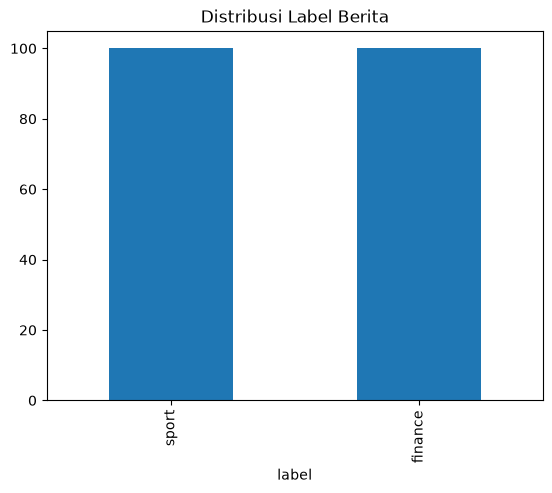

In [4]:
print("Distribusi label:")
print(df['label'].value_counts())

df['label'].value_counts().plot(kind='bar', title='Distribusi Label Berita')

### 1.4 Statistik Panjang Teks

Mengecek panjang (jumlah karakter) tiap dokumen berita: nilai minimum, maksimum, 
rata-rata, dan sebarannya. Ini berguna untuk:
- Mendeteksi outlier (berita yang terlalu pendek/kosong secara efektif, atau 
  terlalu panjang yang mungkin gabungan beberapa artikel)
- Memberi gambaran awal beban komputasi di tahap tokenizing dan stemming nanti

count     200.000000
mean     2442.480000
std      1172.939853
min       130.000000
25%      1836.000000
50%      2333.000000
75%      2902.000000
max      8456.000000
Name: panjang_teks, dtype: float64


<Axes: >

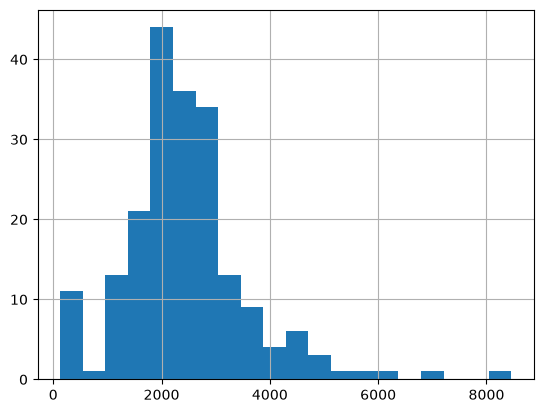

In [5]:
df['panjang_teks'] = df['isi_berita'].str.len()
print(df['panjang_teks'].describe())

df['panjang_teks'].hist(bins=20)

### 1.5 Inspeksi Konten (Cek Noise Hasil Crawling)

Melihat langsung contoh isi berita per label untuk mengecek pola-pola noise 
yang biasanya ikut terambil saat crawling, seperti kata "ADVERTISEMENT", 
"SCROLL TO CONTINUE WITH CONTENT", frasa "Baca juga: ...", atau karakter 
kutip ganda dari escaping CSV. Temuan di sini akan jadi acuan aturan apa saja 
yang perlu dibersihkan di tahap Data Cleaning selanjutnya.

In [6]:
for label in df['label'].unique():
    print(f"\n=== Contoh berita label: {label} ===")
    print(df[df['label'] == label]['isi_berita'].iloc[0][:500])
    print("...")


=== Contoh berita label: sport ===
Jakarta - Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk Asian Games 2026. Dia juga menyebut chemistry satu sama lain sudah klop. Bulutangkis Indonesia mengirimkan 20 wakil untuk tampil di Aichi-Nagoya, 19 September hingga 4 Oktober mendatang. 10 Atlet di antaranya merupakan sektor beregu putri. Yaitu Putri KW, Thalita R. Wiryawan, Ni Kadek Dhinda, Mutiara Ayu Puspitasari, Rachel Allessya Rose, Febi Setianingrum, Febriana Dwipuji Kusuma, Meilysa Trias Pus
...

=== Contoh berita label: finance ===
Jakarta - Penutupan operasional Bandara Soekarno-Hatta beserta sejumlah bandara lain yang terkena dampak abu vulkanik Gunung Anak Krakatau telah berakhir. Mulai Selasa (8/9) pukul 00.01 WIB, operasional bandara kembali berjalan dengan normal. Menteri Perhubungan Dudy Purwagandhi secara langsung menyatakan pembukaan kembali operasional bandara dari Terminal 1 Bandara Soekarno-Hatta, Selasa dini hari (8/9). Sementara ba

In [8]:
%pip install Sastrawi nltk

  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl.metadata (909 bytes)
  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)
Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Data Cleaning & Preprocessing

Setelah memahami karakteristik data di tahap sebelumnya, tahap ini bertujuan 
membersihkan dan menyeragamkan teks berita agar siap diubah menjadi fitur numerik 
(TF-IDF). Tanpa tahap ini, noise (iklan, tag crawling, tanda baca, kata umum) 
akan ikut masuk ke vocabulary dan mengganggu kualitas representasi teks.

Urutan proses:
1. Noise Removal — hapus elemen sisa crawling
2. Case Folding — ubah ke huruf kecil
3. Cleansing — hapus angka & tanda baca
4. Tokenizing — pecah jadi kata per kata
5. Stopword Removal — hapus kata umum tidak bermakna
6. Stemming — ubah kata berimbuhan ke bentuk dasar

### 2.1 Noise Removal

Berdasarkan temuan di Data Understanding (Cell 6), dataset ini mengandung noise 
khas hasil crawling seperti:
- `"SCROLL TO CONTINUE WITH CONTENT"`
- `"ADVERTISEMENT"`
- Pola `"Baca juga: ..."` (biasanya berupa judul artikel lain, bukan isi berita utama)
- Karakter kutip ganda berlebih (`""kata""`) akibat escaping saat proses scraping ke CSV

Noise ini dihapus menggunakan regex sebelum masuk ke tahap cleaning berikutnya, 
supaya tidak dianggap sebagai kata bermakna oleh model.

In [9]:
import re

def remove_noise(text):
    # Hapus frasa noise spesifik hasil crawling
    text = re.sub(r'SCROLL TO CONTINUE WITH CONTENT', ' ', text)
    text = re.sub(r'ADVERTISEMENT', ' ', text)
    # Hapus pola "Baca juga: ..." sampai tanda baca akhir kalimat berikutnya
    text = re.sub(r'Baca juga\s*:.*?(?=\.\s|\n|$)', ' ', text)
    # Rapikan kutip ganda berlebih dari escaping CSV
    text = text.replace('""', '"')
    return text

df['clean_text'] = df['isi_berita'].apply(remove_noise)
df[['isi_berita', 'clean_text']].head(2)

,isi_berita,clean_text
0,Jakarta - Putri Kusuma Wardani percaya diri de...,Jakarta - Putri Kusuma Wardani percaya diri de...
1,Jakarta - Mata Derrick Michael Xzavierro berbi...,Jakarta - Mata Derrick Michael Xzavierro berbi...


### 2.2 Case Folding & Cleansing

- **Case folding**: mengubah semua huruf menjadi huruf kecil, supaya kata yang 
  sama tapi beda kapitalisasi (mis. "Jakarta" dan "jakarta") dihitung sebagai 
  kata yang sama.
- **Cleansing**: menghapus angka, tanda baca, dan karakter selain huruf, karena 
  umumnya tidak berkontribusi signifikan terhadap makna kategori berita 
  (sport vs finance) dalam pendekatan bag-of-words/TF-IDF standar.

In [10]:
def case_folding_cleansing(text):
    text = text.lower()                          # huruf kecil semua
    text = re.sub(r'[^a-z\s]', ' ', text)         # hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()      # rapikan spasi berlebih
    return text

df['clean_text'] = df['clean_text'].apply(case_folding_cleansing)
df[['isi_berita', 'clean_text']].head(2)

,isi_berita,clean_text
0,Jakarta - Putri Kusuma Wardani percaya diri de...,jakarta putri kusuma wardani percaya diri deng...
1,Jakarta - Mata Derrick Michael Xzavierro berbi...,jakarta mata derrick michael xzavierro berbina...


### 2.3 Tokenizing

Memecah setiap dokumen berita menjadi daftar kata (token). Ini adalah langkah 
persiapan sebelum stopword removal dan stemming, karena kedua proses tersebut 
bekerja per kata, bukan per kalimat/dokumen utuh.

In [11]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())
df[['clean_text', 'tokens']].head(2)

,clean_text,tokens
0,jakarta putri kusuma wardani percaya diri deng...,"[jakarta, putri, kusuma, wardani, percaya, dir..."
1,jakarta mata derrick michael xzavierro berbina...,"[jakarta, mata, derrick, michael, xzavierro, b..."


### 2.4 Stopword Removal

Menghapus kata-kata umum Bahasa Indonesia yang sering muncul di hampir semua 
dokumen tapi tidak membawa informasi pembeda antar kategori, misalnya "yang", 
"di", "dan", "ke", "dari". Menggunakan library Sastrawi yang memang dibuat 
khusus untuk Bahasa Indonesia.

In [12]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stopword_factory = StopWordRemoverFactory()
stopwords = set(stopword_factory.get_stop_words())

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)
df[['tokens', 'tokens_no_stopwords']].head(2)

,tokens,tokens_no_stopwords
0,"[jakarta, putri, kusuma, wardani, percaya, dir...","[jakarta, putri, kusuma, wardani, percaya, dir..."
1,"[jakarta, mata, derrick, michael, xzavierro, b...","[jakarta, mata, derrick, michael, xzavierro, b..."


### 2.5 Stemming

Mengubah kata berimbuhan menjadi kata dasarnya, misalnya "bertanding" → "tanding", 
"kekuatan" → "kuat". Tujuannya agar variasi bentuk kata dari akar yang sama 
dihitung sebagai satu fitur yang sama saat ekstraksi fitur nanti.

Catatan: proses ini cukup berat secara komputasi untuk 200 dokumen panjang, 
jadi mungkin butuh waktu beberapa menit untuk selesai.

In [13]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

df['tokens_stemmed'] = df['tokens_no_stopwords'].apply(stem_tokens)
df[['tokens_no_stopwords', 'tokens_stemmed']].head(2)

,tokens_no_stopwords,tokens_stemmed
0,"[jakarta, putri, kusuma, wardani, percaya, dir...","[jakarta, putri, kusuma, wardani, percaya, dir..."
1,"[jakarta, mata, derrick, michael, xzavierro, b...","[jakarta, mata, derrick, michael, xzavierro, b..."


### 2.6 Gabungkan Kembali Token Menjadi Teks Bersih

Setelah semua kata melalui stopword removal dan stemming, token-token tersebut 
digabungkan kembali menjadi satu string per dokumen. Format ini yang nantinya 
menjadi input untuk `TfidfVectorizer` di tahap Ekstraksi Fitur & Representasi TF-IDF.

In [14]:
df['final_text'] = df['tokens_stemmed'].apply(lambda tokens: ' '.join(tokens))
df[['isi_berita', 'final_text']].head(3)

,isi_berita,final_text
0,Jakarta - Putri Kusuma Wardani percaya diri de...,jakarta putri kusuma wardani percaya diri komp...
1,Jakarta - Mata Derrick Michael Xzavierro berbi...,jakarta mata derrick michael xzavierro binar b...
2,Jakarta - Marc Marquez masih harus beradaptasi...,jakarta marc marquez adaptasi kondisi lengan k...


### 2.7 Cek Hasil Preprocessing

Membandingkan teks asli dengan teks hasil preprocessing secara utuh untuk satu 
sampel dokumen, sebagai validasi manual bahwa proses cleaning, stopword removal, 
dan stemming sudah berjalan sesuai harapan sebelum lanjut ke tahap ekstraksi fitur.

In [15]:
print("=== TEKS ASLI ===")
print(df['isi_berita'].iloc[0][:500])

print("\n=== TEKS SETELAH PREPROCESSING ===")
print(df['final_text'].iloc[0][:500])

=== TEKS ASLI ===
Jakarta - Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk Asian Games 2026. Dia juga menyebut chemistry satu sama lain sudah klop. Bulutangkis Indonesia mengirimkan 20 wakil untuk tampil di Aichi-Nagoya, 19 September hingga 4 Oktober mendatang. 10 Atlet di antaranya merupakan sektor beregu putri. Yaitu Putri KW, Thalita R. Wiryawan, Ni Kadek Dhinda, Mutiara Ayu Puspitasari, Rachel Allessya Rose, Febi Setianingrum, Febriana Dwipuji Kusuma, Meilysa Trias Pus

=== TEKS SETELAH PREPROCESSING ===
jakarta putri kusuma wardani percaya diri komposisi regu putri pilih pbsi asi games sebut chemistry satu sama klop bulutangkis indonesia kirim wakil tampil aichi nagoya september hingga oktober datang atlet antara rupa sektor regu putri putri kw thalita r wiryawan ni kadek dhinda mutiara ayu puspitasari rachel allessya rose febi setianingrum febriana dwipuji kusuma meilysa trias puspitasari siti fadia silva ramadhanti nita violina marwah ala

## 3. Ekstraksi Fitur & Representasi Teks

Setelah teks melalui tahap preprocessing (cleaning, stopword removal, stemming), 
langkah berikutnya adalah mengubah teks menjadi representasi numerik agar bisa 
diproses oleh algoritma machine learning. Tahap ini terdiri dari:

1. Membentuk **vocabulary** (kumpulan seluruh kata unik) dari seluruh dokumen (`final_text`)
2. Merepresentasikan dokumen dalam **Binary Document-Term Matrix**
3. Merepresentasikan dokumen dalam **Term Frequency Matrix (Bag of Words)**
4. Merepresentasikan dokumen dalam **TF-IDF Matrix**

Ketiga matriks (Binary, BoW, TF-IDF) dibangun menggunakan **vocabulary yang sama** 
agar kolom-kolom antar tabel bisa dibandingkan secara konsisten. Kolom `label` 
disimpan terpisah dan tidak diikutsertakan sebagai fitur teks.

In [17]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.3 MB 2.8 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.3 MB 2.6 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.3 MB 2.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 2.4 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 2.5 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.3 MB 2.6 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 2.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 2.6 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 MB 2.7 MB/s eta 0:00:02
   ------------------------------ --------- 6.3/8.3 MB 2.8 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 2.9 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Fit CountVectorizer untuk mendapatkan vocabulary dari seluruh dokumen
count_vectorizer = CountVectorizer()
count_vectorizer.fit(df['final_text'])

vocabulary = count_vectorizer.get_feature_names_out()
print("Jumlah kata unik (vocabulary size):", len(vocabulary))
print("\nContoh 20 kata pertama dalam vocabulary:")
print(vocabulary[:20])

Jumlah kata unik (vocabulary size): 4971

Contoh 20 kata pertama dalam vocabulary:
['aadi' 'aan' 'aarhus' 'abad' 'abadi' 'abai' 'abal' 'abang' 'abdul'
 'abdullah' 'abis' 'abraham' 'absen' 'abu' 'ac' 'acara' 'acau' 'access'
 'account' 'accurate']


### 3.2 Pembuatan Tabel 1: Binary Document-Term Matrix

Binary Document-Term Matrix menunjukkan apakah sebuah kata muncul dalam sebuah dokumen. 
Setiap baris mewakili satu artikel, sedangkan setiap kolom mewakili satu kata unik. 
Nilai yang digunakan hanya:

* `1`: kata muncul setidaknya satu kali dalam dokumen;
* `0`: kata tidak muncul dalam dokumen.

Representasi biner mengabaikan jumlah kemunculan kata. Karena itu, dua dokumen yang 
memuat kata yang sama tetap memiliki nilai yang sama meskipun frekuensinya berbeda. 
Kolom `label` disimpan terpisah sebagai target kategori dan bukan sebagai fitur teks.

In [19]:
# Binary Document-Term Matrix, pakai vocabulary yang sama dengan count_vectorizer
binary_vectorizer = CountVectorizer(vocabulary=count_vectorizer.vocabulary_, binary=True)
binary_matrix = binary_vectorizer.fit_transform(df['final_text'])

df_binary = pd.DataFrame(
    binary_matrix.toarray(),
    columns=binary_vectorizer.get_feature_names_out()
)
df_binary['label'] = df['label'].values

print("Ukuran Binary Document-Term Matrix:", df_binary.shape)
df_binary.head()

Ukuran Binary Document-Term Matrix: (200, 4972)


,aadi,aan,aarhus,abad,abadi,abai,abal,abang,abdul,abdullah,...,zaki,zamorano,zapp,zero,zona,zoom,zuhair,zulhas,zulkifli,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport


### 3.3 Pembuatan Tabel 2: Term Frequency Matrix / Bag of Words

Bag of Words merepresentasikan dokumen berdasarkan jumlah kemunculan setiap kata. 
Berbeda dari matriks biner, nilai pada tabel ini dapat lebih besar dari satu. 
Misalnya, jika sebuah kata muncul tiga kali dalam satu artikel, maka nilai fitur 
kata tersebut adalah `3`.

Metode ini sederhana dan dapat menangkap intensitas penggunaan kata, tetapi belum 
mempertimbangkan apakah kata tersebut juga sering muncul pada banyak dokumen lain. 
Matriks hasil pemrosesan teks biasanya memiliki banyak nilai nol sehingga secara 
konsep termasuk matriks berdimensi tinggi dan bersifat sparse.

In [20]:
# Term Frequency Matrix (Bag of Words) menggunakan vocabulary yang sama
bow_matrix = count_vectorizer.transform(df['final_text'])

df_bow = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)
df_bow['label'] = df['label'].values

print("Ukuran Bag of Words Matrix:", df_bow.shape)
print("Tingkat sparsity: {:.2f}%".format(
    100 * (1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1]))
))
df_bow.head()

Ukuran Bag of Words Matrix: (200, 4972)
Tingkat sparsity: 97.58%


,aadi,aan,aarhus,abad,abadi,abai,abal,abang,abdul,abdullah,...,zaki,zamorano,zapp,zero,zona,zoom,zuhair,zulhas,zulkifli,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sport


### 3.4 Pembuatan Tabel 3: TF-IDF Matrix

TF-IDF (Term Frequency–Inverse Document Frequency) menyempurnakan Bag of Words 
dengan mempertimbangkan seberapa penting sebuah kata terhadap suatu dokumen, 
relatif terhadap keseluruhan korpus. Kata yang sering muncul di satu dokumen tapi 
jarang muncul di dokumen lain akan mendapat bobot tinggi, sedangkan kata yang 
muncul di hampir semua dokumen (misalnya kata umum yang lolos dari stopword 
removal) akan mendapat bobot rendah.

Rumus dasarnya:

`TF-IDF(t, d) = TF(t, d) × IDF(t)`

di mana `TF(t, d)` adalah frekuensi kata `t` pada dokumen `d`, dan `IDF(t)` mengukur 
seberapa jarang kata `t` muncul di seluruh dokumen dalam korpus.

In [21]:
# TF-IDF Matrix, pakai vocabulary yang sama agar konsisten dengan tabel sebelumnya
tfidf_vectorizer = TfidfVectorizer(vocabulary=count_vectorizer.vocabulary_)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['final_text'])

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
df_tfidf['label'] = df['label'].values

print("Ukuran TF-IDF Matrix:", df_tfidf.shape)
df_tfidf.head()

Ukuran TF-IDF Matrix: (200, 4972)


,aadi,aan,aarhus,abad,abadi,abai,abal,abang,abdul,abdullah,...,zaki,zamorano,zapp,zero,zona,zoom,zuhair,zulhas,zulkifli,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport


### Verifikasi: Matriks Tidak Nol Semua (hanya sparse)

Karena vocabulary disusun alfabetis, kolom-kolom pertama sering berisi kata-kata 
langka yang wajar tidak muncul di beberapa dokumen pertama — bukan berarti 
matriksnya kosong. Berikut verifikasi total kemunculan kata dan tampilan yang 
lebih representatif menggunakan kata-kata yang paling sering muncul.

In [32]:
# 1. Verifikasi bahwa matriks TIDAK nol semua
print("Total nilai 1 di Binary Matrix     :", df_binary.drop(columns=['label']).values.sum())
print("Total kemunculan kata di BoW Matrix:", df_bow.drop(columns=['label']).values.sum())
print("Total nilai TF-IDF (non-zero)      :", (df_tfidf.drop(columns=['label']).values > 0).sum())

# 2. Cari kata yang paling sering muncul (biar tampilannya ga alfabetis & kosong)
word_freq = df_bow.drop(columns=['label']).sum().sort_values(ascending=False)
top_words = word_freq.head(10).index.tolist()

print("\n10 kata dengan frekuensi tertinggi:")
print(word_freq.head(10))

print("\nContoh Binary Matrix untuk kata-kata yang sering muncul:")
display(df_binary[top_words + ['label']].head())

print("\nContoh BoW Matrix untuk kata-kata yang sering muncul:")
display(df_bow[top_words + ['label']].head())

print("\nContoh TF-IDF Matrix untuk kata-kata yang sering muncul:")
display(df_tfidf[top_words + ['label']].head())

Total nilai 1 di Binary Matrix     : 24080
Total kemunculan kata di BoW Matrix: 44222
Total nilai TF-IDF (non-zero)      : 24080

10 kata dengan frekuensi tertinggi:
jadi         488
sebut        364
indonesia    339
jakarta      313
laku         217
lebih        204
rp           203
hingga       193
sama         183
kata         176
dtype: int64

Contoh Binary Matrix untuk kata-kata yang sering muncul:


,jadi,sebut,indonesia,jakarta,laku,lebih,rp,hingga,sama,kata,label
0,1,1,1,1,0,1,0,1,1,1,sport
1,1,0,1,1,1,0,0,0,0,1,sport
2,1,1,1,1,1,0,0,0,1,1,sport
3,1,0,1,1,0,1,0,1,0,1,sport
4,1,1,1,1,0,0,0,0,0,0,sport



Contoh BoW Matrix untuk kata-kata yang sering muncul:


,jadi,sebut,indonesia,jakarta,laku,lebih,rp,hingga,sama,kata,label
0,1,1,3,1,0,2,0,2,4,1,sport
1,3,0,3,4,1,0,0,0,0,2,sport
2,1,3,2,1,1,0,0,0,2,1,sport
3,3,0,2,1,0,1,0,1,0,2,sport
4,1,2,1,1,0,0,0,0,0,0,sport



Contoh TF-IDF Matrix untuk kata-kata yang sering muncul:


,jadi,sebut,indonesia,jakarta,laku,lebih,rp,hingga,sama,kata,label
0,0.014567,0.017050,0.063270,0.013100,0.000000,0.040909,0.0,0.043249,0.080358,0.019736,sport
1,0.041700,0.000000,0.060371,0.049998,0.019636,0.000000,0.0,0.000000,0.000000,0.037663,sport
2,0.013991,0.049124,0.040510,0.012581,0.019764,0.000000,0.0,0.000000,0.038588,0.018954,sport
3,0.051925,0.000000,0.050116,0.015564,0.000000,0.024303,0.0,0.025693,0.000000,0.046898,sport
4,0.012395,0.029014,0.017945,0.011146,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,sport


## 4. Pembuatan Tabel 4: Principal Component Analysis (PCA)

TF-IDF Matrix yang dihasilkan sebelumnya berdimensi tinggi (jumlah kolom = jumlah 
kata unik dalam vocabulary) dan bersifat sparse (banyak nilai nol). Dimensi yang 
terlalu tinggi dapat menyulitkan visualisasi data dan meningkatkan beban komputasi 
saat modeling.

PCA (Principal Component Analysis) mengatasi hal ini dengan mentransformasikan 
fitur asli menjadi sejumlah kecil **komponen utama (principal component)** yang 
merupakan kombinasi linear dari fitur-fitur TF-IDF, disusun sedemikian rupa 
sehingga:

* PC1 (komponen pertama) menangkap variansi data terbesar,
* PC2 menangkap variansi terbesar berikutnya yang belum tertangkap PC1,
* dan seterusnya, dengan tiap komponen saling tidak berkorelasi (orthogonal).

Kolom `label` tetap disimpan terpisah, hanya sebagai penanda kelas untuk keperluan 
visualisasi — tidak ikut ditransformasi oleh PCA.

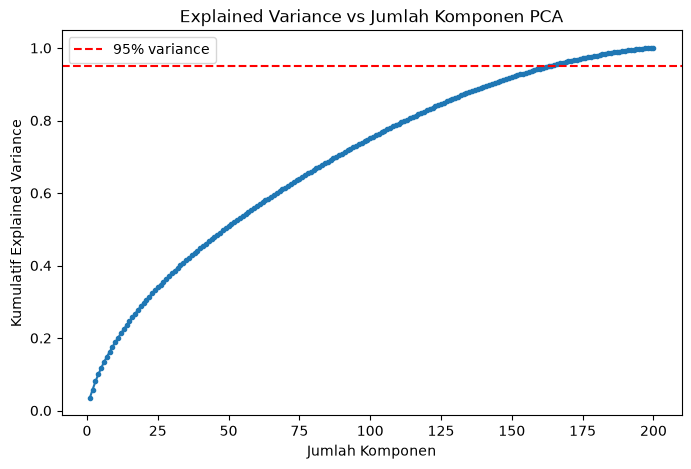

Jumlah komponen untuk menjelaskan >=95% variansi: 164


In [26]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Pisahkan fitur (X) dan label (y) dari TF-IDF Matrix
X_tfidf = df_tfidf.drop(columns=['label']).values
y_label = df_tfidf['label'].values

# Fit PCA dengan seluruh komponen dulu untuk melihat explained variance
pca_full = PCA()
pca_full.fit(X_tfidf)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Explained Variance')
plt.title('Explained Variance vs Jumlah Komponen PCA')
plt.legend()
plt.show()

# Cari jumlah komponen minimal yang menjelaskan >= 95% variansi
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Jumlah komponen untuk menjelaskan >=95% variansi: {n_components_95}")

Berdasarkan grafik *explained variance* di atas, dipilih jumlah komponen yang 
menjelaskan sebagian besar variansi data (>=95%) sebagai jumlah komponen utama 
pada Tabel 4. Selain itu, dibuat juga versi dengan **2 komponen** khusus untuk 
keperluan visualisasi sebaran dokumen antar kelas.

In [23]:
# PCA dengan jumlah komponen yang menjelaskan >=95% variansi
pca_optimal = PCA(n_components=n_components_95, random_state=42)
pca_result = pca_optimal.fit_transform(X_tfidf)

pc_columns = [f'PC{i+1}' for i in range(n_components_95)]
df_pca = pd.DataFrame(pca_result, columns=pc_columns)
df_pca['label'] = y_label

print("Ukuran Tabel PCA:", df_pca.shape)
print(f"Total variansi yang dijelaskan: {pca_optimal.explained_variance_ratio_.sum():.4f}")
df_pca.head()

Ukuran Tabel PCA: (200, 165)
Total variansi yang dijelaskan: 0.9513


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC156,PC157,PC158,PC159,PC160,PC161,PC162,PC163,PC164,label
0,-0.008318,0.058217,-0.018373,0.346111,-0.149779,-0.218551,0.197240,0.014018,0.173862,0.016697,...,-0.061333,0.067102,0.034256,0.087844,-0.021464,0.032358,0.039066,0.041170,0.005583,sport
1,0.020941,0.083306,-0.039582,0.288902,-0.149254,-0.233883,0.196473,-0.092705,0.080646,0.030453,...,-0.028345,-0.021446,-0.041709,-0.051465,0.062705,-0.074594,-0.004334,0.016546,0.027802,sport
2,-0.037684,0.245892,-0.012274,-0.111092,0.003439,-0.052826,0.010294,-0.012622,0.010395,-0.039158,...,0.054887,0.036256,0.009312,0.032722,0.065093,-0.062659,-0.018396,0.055401,-0.019453,sport
3,-0.030074,0.064093,-0.015361,0.262792,-0.110690,-0.205299,0.171379,-0.036842,0.083685,0.079694,...,-0.015873,0.027483,-0.009260,-0.004780,-0.011499,0.010986,-0.015411,0.038019,0.013110,sport
4,0.003825,0.660663,-0.044057,-0.321106,-0.024233,-0.017966,0.031425,-0.026062,0.062312,-0.027661,...,0.054264,0.075236,-0.032295,-0.042737,0.036860,-0.042096,-0.025119,0.122044,-0.055317,sport


### Visualisasi Sebaran Dokumen (PC1 vs PC2)

Untuk melihat apakah dokumen dari kelas berbeda (`sport` dan `finance`) terpisah 
secara alami setelah direduksi dimensinya, dibuat scatter plot menggunakan dua 
komponen utama pertama (PC1 dan PC2).

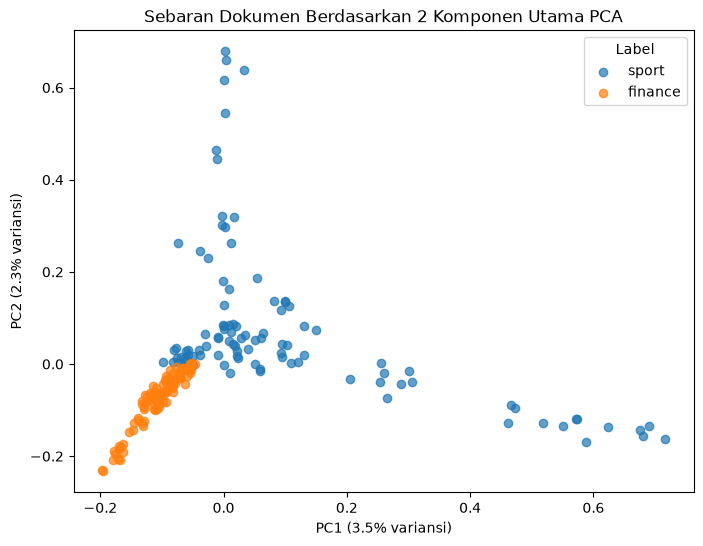

In [24]:
# PCA khusus 2 komponen untuk visualisasi
pca_2d = PCA(n_components=2, random_state=42)
pca_2d_result = pca_2d.fit_transform(X_tfidf)

df_pca_viz = pd.DataFrame(pca_2d_result, columns=['PC1', 'PC2'])
df_pca_viz['label'] = y_label

plt.figure(figsize=(8, 6))
for lbl in df_pca_viz['label'].unique():
    subset = df_pca_viz[df_pca_viz['label'] == lbl]
    plt.scatter(subset['PC1'], subset['PC2'], label=lbl, alpha=0.7)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variansi)')
plt.title('Sebaran Dokumen Berdasarkan 2 Komponen Utama PCA')
plt.legend(title='Label')
plt.show()

TF-IDF Matrix yang dihasilkan sebelumnya berdimensi tinggi (jumlah kolom = jumlah 
kata unik dalam vocabulary) dan bersifat sparse (banyak nilai nol). PCA digunakan 
untuk mereduksi dimensi tersebut menjadi sejumlah kecil **komponen utama (principal 
component)**, yaitu kombinasi linear dari fitur-fitur TF-IDF yang menangkap variansi 
data terbesar.

Pada tahap ini, PCA diterapkan dengan **5 komponen utama (PC1–PC5)**. Kolom `label` 
disimpan terpisah, hanya sebagai penanda kelas dan tidak ikut ditransformasi oleh PCA.

In [27]:
from sklearn.decomposition import PCA
import pandas as pd

# Pisahkan fitur (X) dan label (y) dari TF-IDF Matrix
X_tfidf = df_tfidf.drop(columns=['label']).values
y_label = df_tfidf['label'].values

# PCA dengan 5 komponen utama
pca = PCA(n_components=5, random_state=42)
pca_result = pca.fit_transform(X_tfidf)

# Bentuk Tabel 4
df_pca = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(5)])
df_pca['label'] = y_label

print("Ukuran Tabel PCA:", df_pca.shape)
print("Variansi yang dijelaskan tiap komponen:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {var*100:.2f}%")
print(f"Total variansi yang dijelaskan (5 komponen): {pca.explained_variance_ratio_.sum()*100:.2f}%")

df_pca.head()

Ukuran Tabel PCA: (200, 6)
Variansi yang dijelaskan tiap komponen:
  PC1: 3.47%
  PC2: 2.33%
  PC3: 2.23%
  PC4: 1.94%
  PC5: 1.73%
Total variansi yang dijelaskan (5 komponen): 11.69%


,PC1,PC2,PC3,PC4,PC5,label
0,-0.008314,0.058407,-0.018353,0.345536,-0.147009,sport
1,0.020945,0.083540,-0.039682,0.287587,-0.142862,sport
2,-0.037684,0.246025,-0.012387,-0.111968,0.007698,sport
3,-0.030068,0.064307,-0.015346,0.262026,-0.106500,sport
4,0.003826,0.660679,-0.044010,-0.321369,-0.022655,sport


### Perbandingan Jumlah Kolom Sebelum dan Sesudah PCA

Berikut perbandingan jumlah fitur (kolom) sebelum PCA (TF-IDF Matrix) dan sesudah 
PCA (5 komponen utama), untuk menunjukkan seberapa besar reduksi dimensi yang terjadi.

In [28]:
jumlah_kolom_sebelum = df_tfidf.drop(columns=['label']).shape[1]
jumlah_kolom_sesudah = df_pca.drop(columns=['label']).shape[1]

print(f"Jumlah kolom sebelum PCA (TF-IDF) : {jumlah_kolom_sebelum} kolom")
print(f"Jumlah kolom sesudah PCA          : {jumlah_kolom_sesudah} kolom")
print(f"Reduksi dimensi                   : {jumlah_kolom_sebelum - jumlah_kolom_sesudah} kolom "
      f"({(1 - jumlah_kolom_sesudah/jumlah_kolom_sebelum)*100:.2f}% lebih kecil)")

pd.DataFrame({
    'Tahap': ['Sebelum PCA (TF-IDF)', 'Sesudah PCA'],
    'Jumlah Kolom': [jumlah_kolom_sebelum, jumlah_kolom_sesudah]
})

Jumlah kolom sebelum PCA (TF-IDF) : 4971 kolom
Jumlah kolom sesudah PCA          : 5 kolom
Reduksi dimensi                   : 4966 kolom (99.90% lebih kecil)


,Tahap,Jumlah Kolom
0,Sebelum PCA (TF-IDF),4971
1,Sesudah PCA,5


In [30]:
import os

df_pca.to_csv('hasil_pca_5komponen.csv', index=False)

print("Berhasil disimpan sebagai 'hasil_pca_5komponen.csv'")
print("Lokasi:", os.path.abspath('hasil_pca_5komponen.csv'))

Berhasil disimpan sebagai 'hasil_pca_5komponen.csv'
Lokasi: c:\Users\acer\OneDrive\Documents\DOKUMEN KULIAH\Semester 7\ppw\hasil_pca_5komponen.csv
